# theta_interpretation: multi-seed analysis

Loads several seeds of the two `theta_interpretation` runs (`terms=['x2']`
correct vs. `terms=['x2', 'x4']` misspecified), then:

1. Plots `theta_t` and `Theta_reg` over time for one example seed, and the
   mean +/- std across seeds.
2. Computes the normalization constant `Z` three ways and compares them:
   the MGD lower bound (`codes/utils_entropy.py`'s `log_Z_bound`), a direct
   1D-quadrature reference using the actual fitted theta, and the analytic
   Gaussian `Z` (known exactly here, since the data-generating process
   itself is `N(0, data_sigma^2)`).
3. Uses the fitted models to estimate the probability of a rare event
   (`|X| > 4*sigma`) and a typical one (`|X| < 1*sigma`), against the exact
   analytic answer -- this is the sharpest test of whether the misspecified
   `x^4` term actually hurts anything beyond the bulk moments it was never
   needed for.

This notebook only *defines and runs* the analysis -- it generates its own
data and calls the real SDE solver via `run_SDE.py`'s `run_and_diagnose()`,
so running it end-to-end does real (if small, CPU-cheap) MGD fits; nothing
here is precomputed or faked.


In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.stats import norm

root = Path.cwd()
if not (root / 'run_SDE.py').exists():
    root = root / 'theta_interpretation'  # allow running the notebook from the repo root
sys.path.insert(0, str(root))
sys.path.insert(0, str(root.parent / 'codes'))

from run_SDE import make_args, run_and_diagnose, get_scalar_potentials, device
from utils_entropy import entropy_bound, log_Z_bound  # codes/utils_entropy.py, on sys.path via codes/

# run_SDE.py sets matplotlib.use('Agg') at import time (needed for its own
# headless script use) -- that silently kills inline display here, so switch
# back after importing from it.
%matplotlib inline

print('device:', device)

device: cuda


## 1. Config and multi-seed runs

`N_SEEDS` independent seeds per potential set. Unlike the old version of
this cell, every `make_args` field is now stated explicitly in
`PARAM_OVERRIDES`/`LABELS` below, not left to silently fall back to
`make_args`'s own defaults in `run_SDE.py` -- those defaults are a moving
target (`theta_interpretation.ipynb`'s own `PARAM_OVERRIDES` already
diverges from them) and `build_config_name()`/`build_group_name()`
(`codes/utils_experiment.py`) don't encode `regularization`/`n_subsample`/
`n_bins`/`schedule_exponent`/`interpolant`/`moment_threshold` in the saved
config name at all -- only `label` (plus `n1`/`sigma`/`nt`/`lam`/`terms`)
does. So a `label` mismatch is the single most common reason a rerun with
"the same" parameters fails to find a previous multi-seed sweep on disk.

`run_and_diagnose()` (via `resolve_or_setup_experiment_output` inside it)
already loads a cached run instead of refitting whenever `force_rerun` is
`False` and every one of these fields matches a previous run's saved
config exactly -- so getting `PARAM_OVERRIDES`/`LABELS` right below is
both how you *record* what a sweep used and how you make this cell load it
instead of quietly rerunning it with the wrong hyperparameters.

The defaults below match the `sweep_x2` / `sweep_x2x4` runs already present
under `experiments/` (51 seeds, run on Jean Zay on 2026-09-03) --
`saved_results/` doesn't yet have that run's `.pt` files locally, though
(only `config.json`/`figures`/`logs` were pulled), so this cell will
refit locally until they're pulled with:

```
~/scripts/pull_results.sh jz theta_interpretation/saved_results
```

Change `PARAM_OVERRIDES`/`LABELS`/`N_SEEDS` here for a different sweep.


In [2]:
N_SEEDS = 100
DATA_SIGMA = 1.0
TERM_SETS = {
    'correct (x2)': ['x2'],
    'misspecified (x2, x4)': ['x2', 'x4'],
}
# label per TERM_SETS entry -- must match the label a past sweep was saved
# under (see markdown above); label is NOT implied by `terms` alone.
LABELS = {
    'correct (x2)': 'sweep_x2',
    'misspecified (x2, x4)': 'sweep_x2x4',
}

# Every other make_args field, stated explicitly (see markdown above for
# why silently trusting make_args's own defaults broke loading past runs).
PARAM_OVERRIDES = dict(
    n1=50000, nt=1000, sigma=1.0, schedule_exponent=2, interpolant='Cos',
    regularization=0.001, lam=1e-08, n_subsample=1, batch_size=None,
    n_bins=30, moment_threshold=1e-8, force_rerun=False,
    no_save_aux_moments=False,
)

runs = {label: {} for label in TERM_SETS}
for label, terms in TERM_SETS.items():
    for seed in range(N_SEEDS):
        args = make_args(terms, data_sigma=DATA_SIGMA, seed=seed, outdir=str(root),
                          label=LABELS[label], **PARAM_OVERRIDES)
        runs[label][seed] = run_and_diagnose(args, outdir=root)
    print(f"{label}: {N_SEEDS} seeds done")


2026-09-10 12:51:24  INFO      Reusing existing experiment: thetainterp_sigmadata1.0_sigma1.0_nt1000_n1_50000_lam1e-08_seed_0_terms8e683187_sweep_x2_20260904_1144 (no new folder created)
2026-09-10 12:51:25  INFO      Final theta (order matches ['x2']): [0.42012977600097656]
2026-09-10 12:51:25  INFO      Reference (unverified against this run): for target N(0, data_sigma^2) under p(x) ~ exp(sum_i theta_i * phi_i(x)), theta on x^2 is expected near -0.500000. Fitted theta_x2[-1] = 0.420130
2026-09-10 12:51:25  INFO      Saved diagnostic figures to /lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/theta_interpretation/experiments/thetainterp_sigmadata1.0_sigma1.0_nt1000_n1_50000_lam1e-08_terms8e683187_sweep_x2/thetainterp_sigmadata1.0_sigma1.0_nt1000_n1_50000_lam1e-08_seed_0_terms8e683187_sweep_x2_20260904_1144/figures
2026-09-10 12:51:25  INFO      Reusing existing experiment: thetainterp_sigmadata1.0_sigma1.0_nt1000_n1_50000_lam1e-08_seed_1_terms8e683187_sweep

## 2. Theta trajectories: one example seed, then mean +/- std over seeds

`theta_t` and `Theta_reg` both have the same length across seeds for a
given potential set (the time grid and block-averaging schedule are
deterministic in `nt`/`schedule_exponent`/`n_subsample`, not in the random
data draw), so they can be stacked and averaged directly across the seed
axis.


In [3]:
def stack_over_seeds(runs_for_label, key):
    arrs = [runs_for_label[s]['result'][key].detach().cpu().numpy()
            for s in sorted(runs_for_label)]
    return np.stack(arrs, axis=0)  # (n_seeds, n_steps, n_coef)

def plot_theta_example_and_average(runs_for_label, label, term_names, key, example_seed=0):
    stacked = stack_over_seeds(runs_for_label, key)   # (n_seeds, n_steps, n_coef)
    example = runs_for_label[example_seed]['result'][key].detach().cpu().numpy()
    mean = stacked.mean(0)
    std = stacked.std(0, ddof=1) if stacked.shape[0] > 1 else np.zeros_like(mean)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    steps = np.arange(example.shape[0])
    for i, name in enumerate(term_names):
        axes[0].plot(steps, example[:, i], label=name)
        axes[1].plot(steps, mean[:, i], label=name)
        axes[1].fill_between(steps, mean[:, i] - std[:, i], mean[:, i] + std[:, i], alpha=0.2)
    axes[0].set_title(f'{key}, seed={example_seed} ({label})')
    axes[1].set_title(f'{key}, mean +/- std over {stacked.shape[0]} seeds ({label})')
    for ax in axes:
        ax.set_xlabel('step')
        ax.axhline(0, color='grey', lw=0.5)
        ax.legend()
    fig.tight_layout()
    plt.show()


In [4]:
def plot_relative_variance(runs_for_label, label, term_names,
                            theta_key='theta_t', reg_key='Theta_reg'):
    theta = stack_over_seeds(runs_for_label, theta_key)
    reg   = stack_over_seeds(runs_for_label, reg_key)

    theta_mean, reg_mean = theta.mean(axis=0), reg.mean(axis=0)
    theta_var, reg_var   = theta.var(axis=0, ddof=1), reg.var(axis=0, ddof=1)

    print("theta MGD mean and variance:", theta_mean[-1], theta_var[-1]) 
    print("Theta REG mean and variance:", reg_mean[-1], reg_var[-1]) 
    theta_relvar = theta_var / (theta_mean**2 + 1e-12)
    reg_relvar   = reg_var   / (reg_mean**2   + 1e-12)

    fig, axes = plt.subplots(1, len(term_names), figsize=(5 * len(term_names), 4), squeeze=False)
    axes = axes[0]
    for i, name in enumerate(term_names):
        # theta_t and Theta_reg are on DIFFERENT time grids (Theta_reg's own t_reg
        # isn't saved -- see forward_regularised in sde_routines.py), so each gets
        # its own step-index x-axis, not a shared 't'.
        axes[i].plot(np.arange(theta_relvar.shape[0])[1:], theta_relvar[1:, i], label=r'MGD: $\theta_t$')
        axes[i].plot(np.arange(reg_relvar.shape[0])[1:], reg_relvar[1:, i], label=r'REG: $\Theta_{\rm reg}$')
        axes[i].set_title(name)
        axes[i].set_xlabel('step index')
        axes[i].set_ylabel(r'Relative variance $\mathrm{Var}/\mathrm{mean}^2$')
        axes[i].legend()
        axes[i].grid(alpha=0.2)
    fig.suptitle(f'Relative variance ({label})')
    fig.tight_layout()
    plt.show()

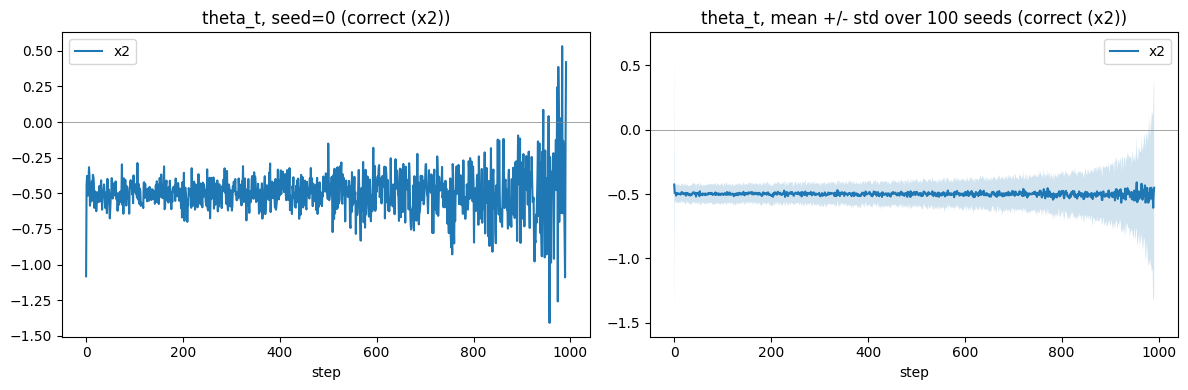

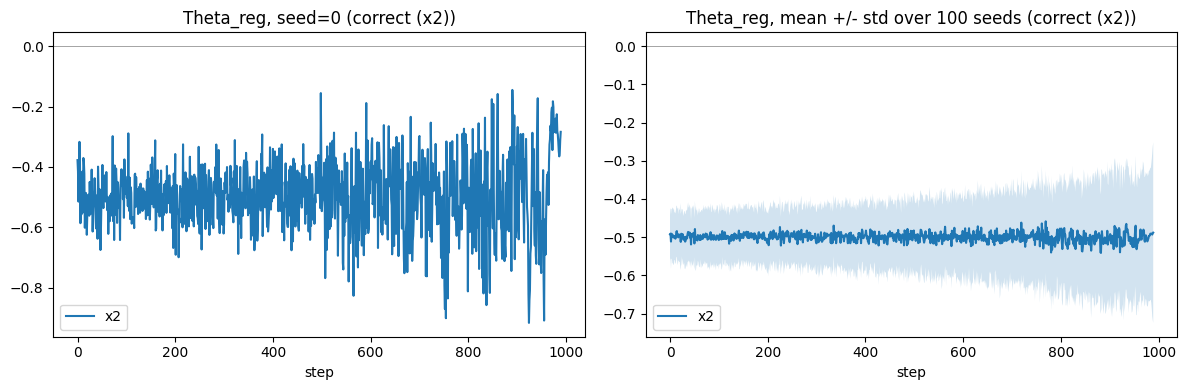

theta MGD mean and variance: [-0.45077628] [0.6971027]
Theta REG mean and variance: [-0.48819256] [0.05582435]


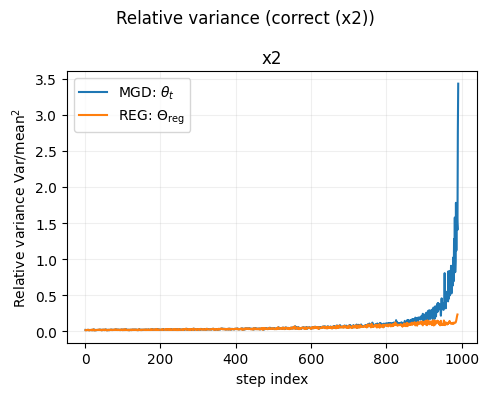

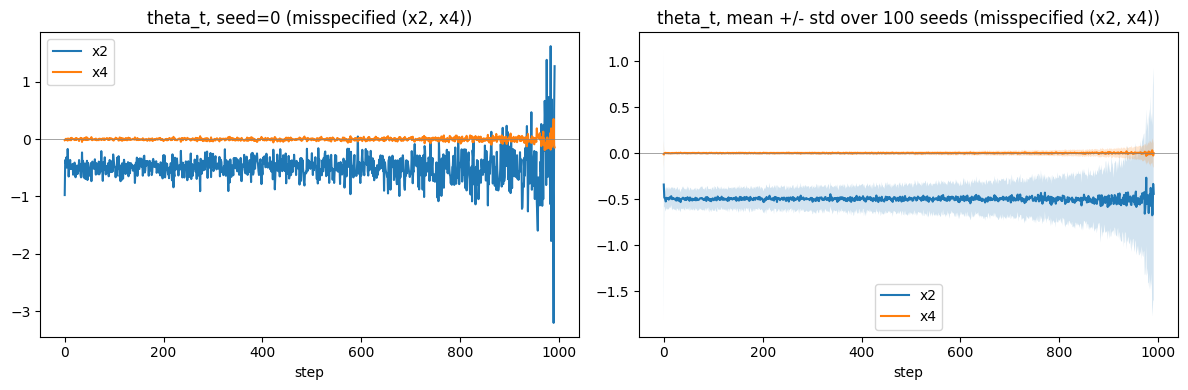

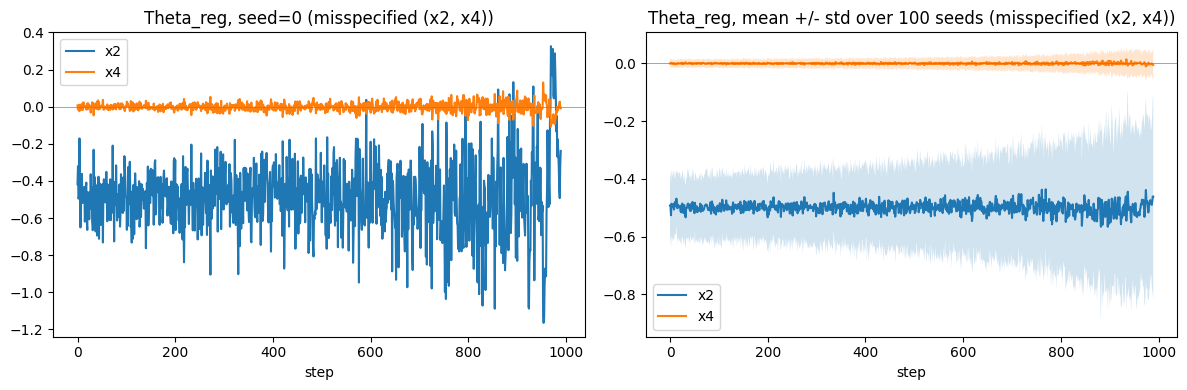

theta MGD mean and variance: [-0.4438648  -0.00098409] [1.3616349  0.02107048]
Theta REG mean and variance: [-0.4609571  -0.00497792] [0.12704162 0.00286876]


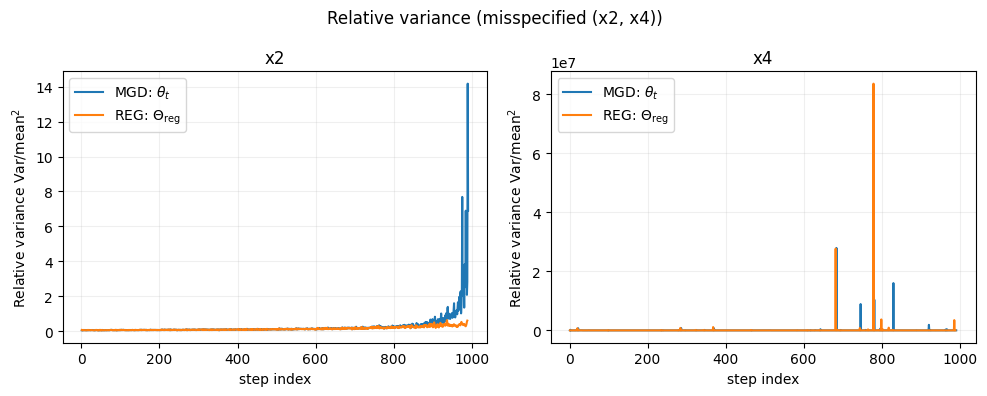

In [5]:
for label, terms in TERM_SETS.items():
    term_names = list(get_scalar_potentials(terms).keys())
    plot_theta_example_and_average(runs[label], label, term_names, 'theta_t')
    plot_theta_example_and_average(runs[label], label, term_names, 'Theta_reg')

    plot_relative_variance(runs[label], label, term_names, theta_key='theta_t', reg_key='Theta_reg')

## 3. Normalization constant: three ways, compared, step by step

Split into five sub-steps so each assumption is visible and checkable on
its own, instead of buried inside one loop:

- **3.1** Extract each seed's final fitted `theta` (`theta_t[-1]`, raw).
- **3.2** Inspect the fitted `theta` values themselves, across seeds --
  BEFORE computing anything nonlinear from them (Z, tail probabilities).
  This is the step that catches a badly off-target fit before it silently
  propagates into every downstream number.
- **3.3** `log_Z_quad`: exact normalizer of the FITTED (possibly
  misspecified) density, via direct 1D quadrature.
- **3.4** `log_Z_bound`: the MGD lower bound, from `codes/utils_entropy.py`,
  reused unchanged.
- **3.5** Compare all three (`analytic`, `quad`, `bound`) across seeds.

**Analytic** (`log_Z_analytic`): the ground truth is known exactly here,
since the data really is `N(0, data_sigma^2)` -- `log Z = 0.5 *
log(2*pi*data_sigma^2)`, the same number regardless of which potential set
was used to fit (a correctly-fit misspecified model should recover
`theta_x4 ~ 0` and hence the same `Z`).

In [6]:
def _degree(term):
    return int(term[1:])  # 'x2' -> 2, 'x4' -> 4


def log_p_unnorm(x, theta, term_names):
    return sum(theta[i] * x ** _degree(t) for i, t in enumerate(term_names))

def _is_normalizable(theta, term_names):
    """exp(θᵀφ) is integrable iff the highest-degree term with a
    nonzero coefficient has even degree and a negative effective coefficient."""
    live = [(_degree(t), theta[i])
            for i, t in enumerate(term_names) if theta[i] != 0.0]
    if not live:
        return False                      # constant, infinite mass
    deg, coef = max(live)
    return deg % 2 == 0 and coef < 0

def log_Z_quad(theta, term_names, x_range=(-50.0, 50.0), label=''):
    """Bound the integration domain by the integrand."""
    if not _is_normalizable(theta, term_names): return float('nan')
    grid = np.linspace(*x_range, 4001)
    log_vals = log_p_unnorm(grid, theta, term_names)
    m = log_vals.max()
    support = grid[log_vals - m > -700.0]          # everything else underflows
    lo, hi = support[0], support[-1]
    modes = list(grid[1:-1][(log_vals[1:-1] > log_vals[:-2]) &
                            (log_vals[1:-1] > log_vals[2:])])
    val, _ = quad(lambda x: np.exp(log_p_unnorm(x, theta, term_names) - m),
                  lo, hi, points=modes, limit=200)
    return m + np.log(val)


def log_tail_probability(theta, term_names, log_Z, a, b=np.inf):
    if not np.isfinite(log_Z):
        return float('nan')
    hi = min(b, a + 50.0) if not np.isfinite(b) else b
    s = log_p_unnorm(np.linspace(a, hi, 2001), theta, term_names).max()
    val, _ = quad(lambda x: np.exp(log_p_unnorm(x, theta, term_names) - s),
                  a, b, limit=200)
    return s + np.log(val) - log_Z


### 3.1 Extract each seed's final fitted theta

**Assumption:** we treat `theta_t[-1]` -- the raw fitted theta at the
final time step of its own trajectory -- as "the" converged fit for each
seed; convergence is NOT verified here, only the value is extracted.
`THETA_FINAL`, and everything computed from it in 3.2-3.5 and section 4,
is therefore on the RAW trajectory, not the regularised `Theta_reg[-1]`.

`Theta_reg` (fit on its own coarser, separately time-subsampled grid --
see `codes/utils_entropy.py`'s `log_Z_bound` docstring) is still used
elsewhere: directly, on its own, by 3.4's `log_Z_bound` call, and in
3.2's raw-vs-regularized `theta_x4` sign comparison -- but `THETA_FINAL`
itself does not hold it.

In [7]:
THETA_FINAL = {label: {} for label in TERM_SETS}
REG_FINAL = {label: {} for label in TERM_SETS}
for label, terms in TERM_SETS.items():
    for seed, run in runs[label].items():
        THETA_FINAL[label][seed] = run['result']['theta_t'][-1].detach().cpu().numpy()
        REG_FINAL[label][seed] = run['result']['Theta_reg'][-1].detach().cpu().numpy()
        
print('Extracted theta_final (theta_t[-1]) for',
      {l: len(d) for l, d in THETA_FINAL.items()}, 'seeds per label')


Extracted theta_final (theta_t[-1]) for {'correct (x2)': 100, 'misspecified (x2, x4)': 100} seeds per label


### 3.2 Inspect the fitted theta distribution across seeds

Every downstream quantity in this notebook (`log_Z_quad`, tail
probabilities) is a NONLINEAR function of `theta` -- a seed whose `theta`
is only mildly off-target can produce a wildly-off `Z` or tail
probability. Looking at `theta` itself, here, is what actually diagnoses
fit quality; the aggregate statistics in 3.5/4.4 cannot by themselves
distinguish "all seeds slightly biased" from "one seed badly off,
dragging the mean" without this step.

**Assumption:** the reference target `theta_x2 = -1/(2*data_sigma^2)`
(dashed line below) comes from matching the quadratic term of
`-log N(0, data_sigma^2)`; it assumes the fit has fully converged to the
true density -- which is exactly what this plot lets you check instead
of assume.


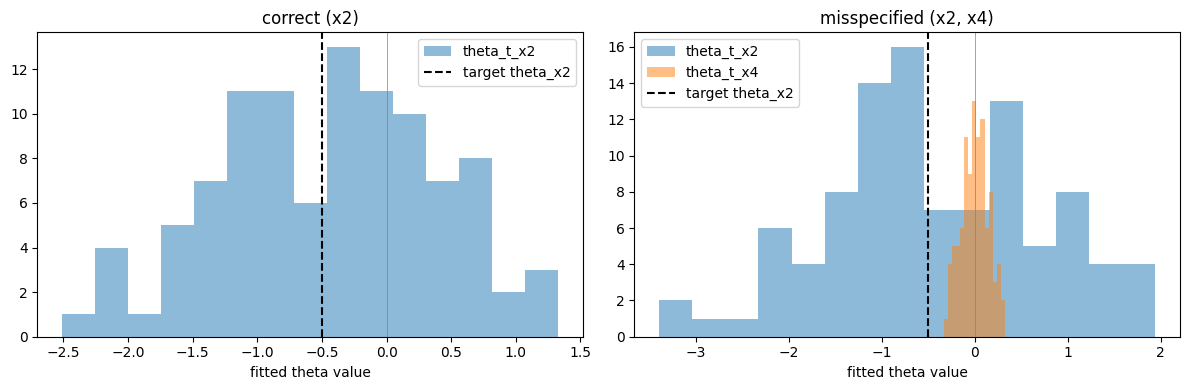

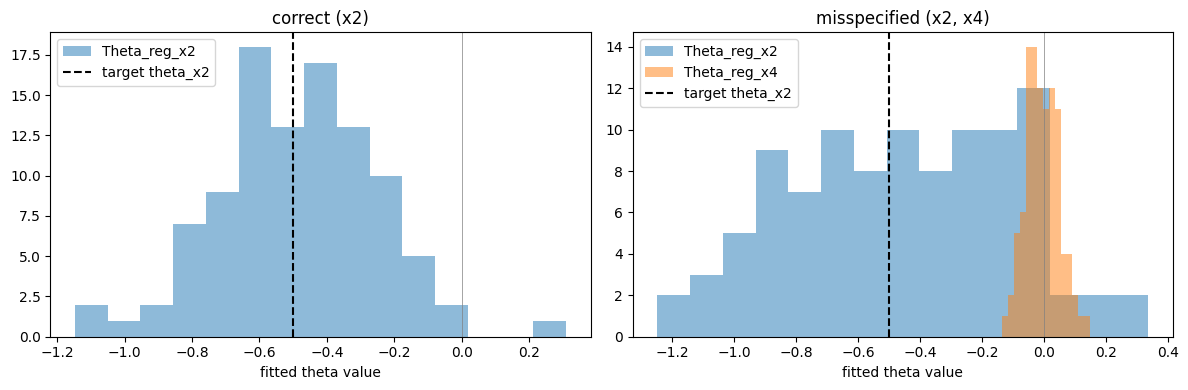

--- correct (x2) (theta_t) ---
  theta_t_x2: mean=-0.4508  std=0.8349  min=-2.5093  max=1.3264
--- correct (x2) (Theta_reg) ---
  Theta_reg_x2: mean=-0.4882  std=0.2363  min=-1.1471  max=0.3097

--- misspecified (x2, x4) (theta_t) ---
  theta_t_x2: mean=-0.4439  std=1.1669  min=-3.3911  max=1.9412
  theta_t_x4: mean=-0.0010  std=0.1452  min=-0.3321  max=0.3249
--- misspecified (x2, x4) (Theta_reg) ---
  Theta_reg_x2: mean=-0.4610  std=0.3564  min=-1.2478  max=0.3366
  Theta_reg_x4: mean=-0.0050  std=0.0536  min=-0.1348  max=0.1480
  theta_x4 sign: theta_x4* = 0 exactly, which sits on the boundary of the feasible set (deg 4, coef 0 is the degenerate case between confining and non-confining) -- so the sign of a noisy estimate of zero is close to a coin flip, not evidence of a failed fit by itself.
    raw (theta_t[-1]):           50/100 positive (50%)
    regularized (Theta_reg[-1]): 45/100 positive (45%)
    -> the regularizer shifting positive-sign frequency from 50% to 45% is itself a

In [8]:
target_theta_x2 = -1.0 / (2 * DATA_SIGMA ** 2)

for FINAL, title in [(THETA_FINAL, 'theta_t'), (REG_FINAL, 'Theta_reg')]:
    fig, axes = plt.subplots(1, len(TERM_SETS), figsize=(6 * len(TERM_SETS), 4))
    if len(TERM_SETS) == 1: axes = [axes]
    for ax, (label, terms) in zip(axes, TERM_SETS.items()):
        names = list(get_scalar_potentials(terms).keys())
        mat = np.stack([FINAL[label][s] for s in sorted(FINAL[label])])
        for i, name in enumerate(names):
            ax.hist(mat[:, i], bins=15, alpha=0.5, label=f'{title}_{name}')
        ax.axvline(target_theta_x2, color='k', ls='--', label='target theta_x2')
        ax.axvline(0, color='grey', lw=0.5)
        ax.set_title(label); ax.set_xlabel('fitted theta value'); ax.legend()
    fig.tight_layout(); plt.show()

for label, terms in TERM_SETS.items():
    term_names = list(get_scalar_potentials(terms).keys())
    seeds_sorted = sorted(THETA_FINAL[label])
    theta_mat = np.stack([THETA_FINAL[label][s] for s in seeds_sorted])
    theta_reg_mat = np.stack([REG_FINAL[label][s] for s in seeds_sorted])
    for mat, title in [(theta_mat, 'theta_t'), (theta_reg_mat, 'Theta_reg')]:
        print(f"--- {label} ({title}) ---")
        for i, name in enumerate(term_names):
            col = mat[:, i]
            print(f"  {title}_{name}: mean={col.mean():.4f}  std={col.std(ddof=1):.4f}  "
                  f"min={col.min():.4f}  max={col.max():.4f}")
    if 'x4' in term_names:
        i4 = term_names.index('x4')
        n = theta_mat.shape[0]
        n_pos_raw = int((theta_mat[:, i4] > 0).sum())
        n_pos_reg = int((theta_reg_mat[:, i4] > 0).sum())
        print(f"  theta_x4 sign: theta_x4* = 0 exactly, which sits on the boundary of "
              f"the feasible set (deg 4, coef 0 is the degenerate case between "
              f"confining and non-confining) -- so the sign of a noisy estimate of "
              f"zero is close to a coin flip, not evidence of a failed fit by itself.")
        print(f"    raw (theta_t[-1]):           {n_pos_raw}/{n} positive ({100*n_pos_raw/n:.0f}%)")
        print(f"    regularized (Theta_reg[-1]): {n_pos_reg}/{n} positive ({100*n_pos_reg/n:.0f}%)")
        print(f"    -> the regularizer shifting positive-sign frequency from "
              f"{100*n_pos_raw/n:.0f}% to {100*n_pos_reg/n:.0f}% is itself a real, "
              f"reportable effect of the regularizer on this near-zero coefficient.")
    print()


### 3.3 Normalization constant via quadrature (`log_Z_quad`)

Exact normalizer of the density the FIT actually produced (not the
ground truth), via `scipy.integrate.quad` over `x_range=(-50, 50)`.

**Assumptions, stated explicitly:**
- **Sign convention**: `p(x) ~ exp(+theta^T phi(x))`, matching
  `codes/utils_entropy.py`'s sign-convention audit (this codebase's
  `theta` is the negative of the MGD paper's).
- **Integration range**: `x_range=(-50, 50)` is assumed wide enough to
  contain all the probability mass; this is NOT verified per seed.
- **Non-normalizability check**: `exp(θᵀφ)` is integrable iff the highest-degree term with a nonzero coefficient has even degree and a negative coefficient. For `terms=['x2','x4']` this means `theta_x4 < 0`. The check is currently a heuristic — the coarse grid's argmax is tested for being at the boundary — which fires whenever `theta_x4 > |theta_x2|/2500` but misses smaller positive values, for which quad returns a finite value set by the truncation at ±50 rather than by the density. n_valid should therefore be read as an upper bound on the number of normalizable fits until the exact test replaces the heuristic.


In [9]:
LOG_Z_QUAD = {label: {} for label in TERM_SETS}
REG_Z_QUAD = {label: {} for label in TERM_SETS}
for label, terms in TERM_SETS.items():
    term_names = list(get_scalar_potentials(terms).keys())
    for seed in sorted(THETA_FINAL[label]):
        LOG_Z_QUAD[label][seed] = log_Z_quad(THETA_FINAL[label][seed], term_names,
                                              label=f'({label}, seed={seed})')
        REG_Z_QUAD[label][seed] = log_Z_quad(REG_FINAL[label][seed], term_names,
                                              label=f'({label}, seed={seed}, reg)')

for label in TERM_SETS:
    vals = np.array(list(LOG_Z_QUAD[label].values()))
    n_valid = int(np.isfinite(vals).sum())
    print(f"{label} (theta_t): {n_valid}/{len(vals)} seeds normalizable (log_Z_quad finite)")
    reg_vals = np.array(list(REG_Z_QUAD[label].values()))
    n_valid_reg = int(np.isfinite(reg_vals).sum())
    print(f"{label} (Theta_reg): {n_valid_reg}/{len(reg_vals)} seeds normalizable (log_Z_quad finite)")


/tmp/xpython_3159478/1924443533.py:28: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  val, _ = quad(lambda x: np.exp(log_p_unnorm(x, theta, term_names) - m),


correct (x2) (theta_t): 68/100 seeds normalizable (log_Z_quad finite)
correct (x2) (Theta_reg): 99/100 seeds normalizable (log_Z_quad finite)
misspecified (x2, x4) (theta_t): 50/100 seeds normalizable (log_Z_quad finite)
misspecified (x2, x4) (Theta_reg): 55/100 seeds normalizable (log_Z_quad finite)


### 3.4 Normalization constant via the MGD bound (`log_Z_bound`)

**Assumption:** reused as-is from `codes/utils_entropy.py`, not
reimplemented or re-derived here. `log_Z_bound` is a LOWER bound on the
true `log Z_theta1` -- the normalizer of the FITTED theta1 (i.e. what
3.3's `log_Z_quad` computes exactly for that same theta1), not on
`log_Z_analytic` -- so `log_Z_quad - log_Z_bound >= 0` per seed (checked
in 3.5) is the actual check on the bound's validity, not on fit quality.
`log_Z_analytic - log_Z_quad` is a separate quantity (also reported in
3.5): how far the fit itself is from the true data-generating density.

Unlike 3.3, this does NOT require the fitted density to be normalizable
-- it's computed independently of whether `exp(theta^T phi(x))` diverges
at infinity, so it's reported for every seed here, including the ones
3.3 flagged as non-normalizable.

In [10]:
LOG_Z_BOUND = {label: {} for label in TERM_SETS}
REG_Z_BOUND = {label: {} for label in TERM_SETS}
for label, terms in TERM_SETS.items():
    potentials = get_scalar_potentials(terms)
    for seed, run in runs[label].items():
        single = {f'seed{seed}': run['result']}
        out = log_Z_bound(single, f'seed{seed}', 'theta_t', potentials, device=device)
        LOG_Z_BOUND[label][seed] = out['log_Z_bound']
        out_reg = log_Z_bound(single, f'seed{seed}', 'Theta_reg', potentials, device=device)
        REG_Z_BOUND[label][seed] = out_reg['log_Z_bound']

print('log_Z_bound (theta_t) computed for', {l: len(d) for l, d in LOG_Z_BOUND.items()}, 'seeds per label')
print('log_Z_bound (Theta_reg) computed for', {l: len(d) for l, d in REG_Z_BOUND.items()}, 'seeds per label')


log_Z_bound (theta_t) computed for {'correct (x2)': 100, 'misspecified (x2, x4)': 100} seeds per label
log_Z_bound (Theta_reg) computed for {'correct (x2)': 100, 'misspecified (x2, x4)': 100} seeds per label


### 3.5 Compare analytic vs. quadrature vs. bound, across seeds

**Assumption:** both mean+/-std (this codebase's own convention for
across-seed aggregation, e.g. `codes/utils_entropy.py`'s
`summarize_log_Z_bound`) and the median are reported side by side. The
median is included because 3.2 already showed the fitted `theta` is not
tightly clustered around its target -- when that's true, `log_Z_quad`'s
across-seed distribution need not be symmetric/light-tailed either, and a
large mean/median gap below is itself evidence the mean is being
dominated by a few outlier seeds, not that "the fit is that biased on
average."

`log_Z_quad`'s mean/median are computed only over the seeds 3.3 flagged
as normalizable, via one explicit `np.isfinite` mask reused for both
`n_valid` and the aggregates below (not `np.nanmean`/`np.nanmedian`,
which silently keep a `-inf` entry out of `n_valid`'s count but not out
of the mean it computes -- this notebook hit exactly that inconsistency
before the fix). `log_Z_bound`'s aggregates are over all seeds (see 3.4).

Two distinct comparisons are reported, not to be conflated:
- **bound check**, `log_Z_quad - log_Z_bound >= 0` per (normalizable)
  seed -- validity of the MGD lower bound against the exact normalizer
  of that seed's own fitted theta1 (see 3.4).
- **fit error**, `log_Z_analytic - log_Z_quad` -- how far the fit's own
  (exact) normalizer is from the true data-generating one; a fit-quality
  measure, unrelated to the bound's validity.

In [11]:
log_Z_analytic = 0.5 * np.log(2 * np.pi * DATA_SIGMA ** 2)
print(f"log_Z_analytic = {log_Z_analytic:.4f}\n")

Z_rows = []
for label in TERM_SETS:
    print(f"--- {label} ---")
    for title, ZQ, ZB in [('theta_t', LOG_Z_QUAD, LOG_Z_BOUND), ('Theta_reg', REG_Z_QUAD, REG_Z_BOUND)]:
        seeds_sorted = sorted(ZQ[label])
        quad_vals = np.array([ZQ[label][s] for s in seeds_sorted])
        bound_vals = np.array([ZB[label][s] for s in seeds_sorted])

        valid = np.isfinite(quad_vals)          # single mask -- drives n_valid AND the aggregates
        n_valid = int(valid.sum())
        quad_valid = quad_vals[valid]
        quad_mean = quad_valid.mean() if n_valid else np.nan
        quad_std = quad_valid.std(ddof=1) if n_valid > 1 else np.nan
        quad_median = np.median(quad_valid) if n_valid else np.nan

        print(f"  [{title}] log_Z_quad  (n_valid={n_valid}/{len(quad_vals)}): "
              f"mean={quad_mean:.4f} +/- {quad_std:.4f}   median={quad_median:.4f}")
        print(f"  [{title}] log_Z_bound (n={len(bound_vals)}):            "
              f"mean={bound_vals.mean():.4f} +/- {bound_vals.std(ddof=1):.4f}   "
              f"median={np.median(bound_vals):.4f}")
        print(f"  [{title}] log_Z_analytic:                     {log_Z_analytic:.4f}")

        # Bound check: log_Z_bound is a lower bound on THIS seed's own log Z_theta1
        # (= log_Z_quad, exactly), not on log_Z_analytic -- so only meaningful, and
        # only checked, on the seeds log_Z_quad is finite for.
        bound_gap = quad_valid - bound_vals[valid]
        n_violations = int((bound_gap < 0).sum())
        print(f"  [{title}] bound check (log_Z_quad - log_Z_bound >= 0): "
              f"{n_valid - n_violations}/{n_valid} normalizable seeds satisfy it"
              + (f"  (worst violation: {bound_gap.min():.4f})" if n_violations else ""))

        # Fit error: distinct from the bound check -- how far the FIT's own exact
        # normalizer is from the true data-generating one.
        fit_error = log_Z_analytic - quad_valid
        print(f"  [{title}] fit error (log_Z_analytic - log_Z_quad): "
              f"mean={fit_error.mean():.4f}   median={np.median(fit_error):.4f}")

        Z_rows.append({
            'label': label, 'theta_variant': title,
            'log_Z_quad_mean': quad_mean, 'log_Z_quad_median': quad_median,
            'log_Z_quad_std': quad_std,
            'log_Z_bound_mean': bound_vals.mean(), 'log_Z_bound_median': np.median(bound_vals),
            'log_Z_bound_std': bound_vals.std(ddof=1),
            'bound_check_n_valid': n_valid, 'bound_check_violations': n_violations,
            'fit_error_mean': fit_error.mean(), 'fit_error_median': np.median(fit_error),
        })
    print()


log_Z_analytic = 0.9189

--- correct (x2) ---
  [theta_t] log_Z_quad  (n_valid=68/100): mean=0.8269 +/- 0.5530   median=0.6529
  [theta_t] log_Z_bound (n=100):            mean=0.9711 +/- 0.8331   median=1.0530
  [theta_t] log_Z_analytic:                     0.9189
  [theta_t] bound check (log_Z_quad - log_Z_bound >= 0): 66/68 normalizable seeds satisfy it  (worst violation: -0.0018)
  [theta_t] fit error (log_Z_analytic - log_Z_quad): mean=0.0920   median=0.2661
  [Theta_reg] log_Z_quad  (n_valid=99/100): mean=0.9920 +/- 0.3064   median=0.9143
  [Theta_reg] log_Z_bound (n=100):            mean=0.9338 +/- 0.2358   median=0.9247
  [Theta_reg] log_Z_analytic:                     0.9189
  [Theta_reg] bound check (log_Z_quad - log_Z_bound >= 0): 82/99 normalizable seeds satisfy it  (worst violation: -0.0052)
  [Theta_reg] fit error (log_Z_analytic - log_Z_quad): mean=-0.0731   median=0.0047

--- misspecified (x2, x4) ---
  [theta_t] log_Z_quad  (n_valid=50/100): mean=2.3091 +/- 1.8784   med

## 4. Rare-event vs. typical-event probability, step by step

Reuses `THETA_FINAL`/`LOG_Z_QUAD`/`LOG_Z_BOUND` from section 3 instead of
recomputing them (the previous version of this notebook called
`log_Z_quad` a second time here, independently of section 3 -- same
result, duplicate work, duplicate warnings, and two places that could
silently drift apart).

Rare event: `|X| > 4*data_sigma`. Typical event: `|X| < 1*data_sigma`
(defaults -- change `RARE_THRESHOLD`/`TYPICAL_THRESHOLD` in 4.1).

- **4.1** Thresholds and the analytic (true) probabilities.
- **4.2** `P_quad`: probability under the FITTED density's own normalizer
  (`log_Z_quad`, from 3.3) -- tells you how good the fit is (bulk +
  tails), independent of the MGD bound's own looseness.
- **4.3** `P_bound_upper`: probability using `log_Z_bound` (from 3.4)
  instead of the true `Z`. Since `log_Z_bound <= log_Z_true`,
  `1/Z_bound >= 1/Z_true`, so this is an UPPER BOUND on the true
  probability, not an estimate -- included to show how much a naive use
  of the bound would distort a rare-event estimate.
- **4.4** Aggregate across seeds (mean and median, same caveat as 3.5).

**Assumption carried over from 3.3:** a seed flagged non-normalizable
there (`log_Z_quad` = nan) is skipped for BOTH `P_quad` and
`P_bound_upper` here, even though `log_Z_bound` itself is finite for
that seed -- because a non-confining `theta` (e.g. positive `theta_x4`)
makes the truncated tail integral `int_a^inf exp(theta^T phi(x)) dx`
diverge too, independently of which `log_Z` you'd subtract.


In [12]:
RARE_THRESHOLD = 4 * DATA_SIGMA
TYPICAL_THRESHOLD = 1 * DATA_SIGMA

P_rare_true = 2 * norm.sf(RARE_THRESHOLD / DATA_SIGMA)         # two-sided |X| > 4 sigma
P_typical_true = 2 * norm.cdf(TYPICAL_THRESHOLD / DATA_SIGMA) - 1  # |X| < 1 sigma

print(f"True (analytic) P(|X| > {RARE_THRESHOLD}) = {P_rare_true:.6e}")
print(f"True (analytic) P(|X| < {TYPICAL_THRESHOLD}) = {P_typical_true:.6e}")


True (analytic) P(|X| > 4.0) = 6.334248e-05
True (analytic) P(|X| < 1.0) = 6.826895e-01


### 4.2 P_quad: tail probability under the fitted density

**Assumption:** uses `LOG_Z_QUAD[label][seed]` and `THETA_FINAL[label][seed]`
from section 3 directly -- not recomputed. Seeds where 3.3 found
`log_Z_quad = nan` are skipped (`nan` propagated instead).

Everything here is kept in log space (`LOG_P_RARE_QUAD`/`LOG_P_TYP_QUAD`)
and only exponentiated at print time, in 4.4 -- these are tail
probabilities that can span many orders of magnitude, so aggregating
(mean/median) in log space and exponentiating the aggregate, rather than
exponentiating each seed first, avoids a handful of extreme seeds
dominating a linear-space mean.

The two-sided rare probability `P(|X|>t) = P(X>t) + P(X<-t)` is combined
via `np.logaddexp(log_p_upper, log_p_lower)` -- i.e. `log(a + b)`, not
`log_p_upper + log_p_lower` (which is `log(a * b)`, a different and much
smaller quantity).

In [13]:
LOG_P_RARE_QUAD = {label: {} for label in TERM_SETS}
LOG_P_TYP_QUAD = {label: {} for label in TERM_SETS}
REG_P_RARE_QUAD = {label: {} for label in TERM_SETS}
REG_P_TYP_QUAD = {label: {} for label in TERM_SETS}
for label, terms in TERM_SETS.items():
    term_names = list(get_scalar_potentials(terms).keys())
    for seed in sorted(THETA_FINAL[label]):
        theta_1 = THETA_FINAL[label][seed]
        lZ_quad = LOG_Z_QUAD[label][seed]
        if not np.isfinite(lZ_quad):
            LOG_P_RARE_QUAD[label][seed] = np.nan
            LOG_P_TYP_QUAD[label][seed] = np.nan
        else:
            log_p_upper = log_tail_probability(theta_1, term_names, lZ_quad, RARE_THRESHOLD, np.inf)
            log_p_lower = log_tail_probability(theta_1, term_names, lZ_quad, -np.inf, -RARE_THRESHOLD)
            LOG_P_RARE_QUAD[label][seed] = np.logaddexp(log_p_upper, log_p_lower)  # log(P_upper + P_lower)
            LOG_P_TYP_QUAD[label][seed] = log_tail_probability(theta_1, term_names, lZ_quad,
                                                                 -TYPICAL_THRESHOLD, TYPICAL_THRESHOLD)

        theta_1_reg = REG_FINAL[label][seed]
        lZ_quad_reg = REG_Z_QUAD[label][seed]
        if not np.isfinite(lZ_quad_reg):
            REG_P_RARE_QUAD[label][seed] = np.nan
            REG_P_TYP_QUAD[label][seed] = np.nan
        else:
            log_p_upper_reg = log_tail_probability(theta_1_reg, term_names, lZ_quad_reg, RARE_THRESHOLD, np.inf)
            log_p_lower_reg = log_tail_probability(theta_1_reg, term_names, lZ_quad_reg, -np.inf, -RARE_THRESHOLD)
            REG_P_RARE_QUAD[label][seed] = np.logaddexp(log_p_upper_reg, log_p_lower_reg)
            REG_P_TYP_QUAD[label][seed] = log_tail_probability(theta_1_reg, term_names, lZ_quad_reg,
                                                                 -TYPICAL_THRESHOLD, TYPICAL_THRESHOLD)

print('log P_quad computed (theta_t + Theta_reg; log-space; nan for seeds flagged non-normalizable) '
      '-- exponentiated only at print time, in 4.4')


/lustre/fshomisc/sup/pub/miniforge/24.11.3/envs/pytorch-gpu-2.8.0+py3.12.11/lib/python3.12/site-packages/numpy/_core/function_base.py:162: RuntimeWarning: invalid value encountered in multiply
  y *= step
/lustre/fshomisc/sup/pub/miniforge/24.11.3/envs/pytorch-gpu-2.8.0+py3.12.11/lib/python3.12/site-packages/numpy/_core/function_base.py:172: RuntimeWarning: invalid value encountered in add
  y += start
/tmp/xpython_3159478/1924443533.py:38: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  val, _ = quad(lambda x: np.exp(log_p_unnorm(x, theta, term_names) - s),
/tmp/xpython_3159478/17740851.py:28: RuntimeWarning: invalid value encountered in logaddexp
  REG_P_RARE_QUAD[label][seed] = np.logaddexp(log_p_upper_reg, log_p_lower_reg)
/tmp/xpython_3159478/17740851.py:16: RuntimeWarning: invalid value encountered in logaddexp
  LOG_P_RARE_QUAD[label][seed] = np.logaddexp(log_p

log P_quad computed (theta_t + Theta_reg; log-space; nan for seeds flagged non-normalizable) -- exponentiated only at print time, in 4.4


### 4.3 P_bound_upper: tail probability implied by the MGD bound

**Assumption:** NOT an estimate of the true tail probability -- see the
sign argument in the section intro. Uses `LOG_Z_BOUND[label][seed]` from
3.4, but is still skipped for seeds 3.3 flagged non-normalizable (see
the section intro for why that coupling holds even though `log_Z_bound`
itself is finite for those seeds).

Same conventions as 4.2: kept in log space (`LOG_P_RARE_BOUND`), the
two-sided probability combined via `np.logaddexp`, exponentiated only at
print time in 4.4.

In [14]:
LOG_P_RARE_BOUND = {label: {} for label in TERM_SETS}
REG_P_RARE_BOUND = {label: {} for label in TERM_SETS}
for label, terms in TERM_SETS.items():
    term_names = list(get_scalar_potentials(terms).keys())
    for seed in sorted(THETA_FINAL[label]):
        if not np.isfinite(LOG_Z_QUAD[label][seed]):
            LOG_P_RARE_BOUND[label][seed] = np.nan
        else:
            theta_1 = THETA_FINAL[label][seed]
            lZ_bound = LOG_Z_BOUND[label][seed]
            log_p_upper = log_tail_probability(theta_1, term_names, lZ_bound, RARE_THRESHOLD, np.inf)
            log_p_lower = log_tail_probability(theta_1, term_names, lZ_bound, -np.inf, -RARE_THRESHOLD)
            LOG_P_RARE_BOUND[label][seed] = np.logaddexp(log_p_upper, log_p_lower)  # log(P_upper + P_lower)

        if not np.isfinite(REG_Z_QUAD[label][seed]):
            REG_P_RARE_BOUND[label][seed] = np.nan
        else:
            theta_1_reg = REG_FINAL[label][seed]
            lZ_bound_reg = REG_Z_BOUND[label][seed]
            log_p_upper_reg = log_tail_probability(theta_1_reg, term_names, lZ_bound_reg, RARE_THRESHOLD, np.inf)
            log_p_lower_reg = log_tail_probability(theta_1_reg, term_names, lZ_bound_reg, -np.inf, -RARE_THRESHOLD)
            REG_P_RARE_BOUND[label][seed] = np.logaddexp(log_p_upper_reg, log_p_lower_reg)

print('log P_bound_upper computed (theta_t + Theta_reg) -- exponentiated only at print time, in 4.4')


/tmp/xpython_3159478/1924443533.py:38: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  val, _ = quad(lambda x: np.exp(log_p_unnorm(x, theta, term_names) - s),
/tmp/xpython_3159478/713542927.py:22: RuntimeWarning: invalid value encountered in logaddexp
  REG_P_RARE_BOUND[label][seed] = np.logaddexp(log_p_upper_reg, log_p_lower_reg)
/tmp/xpython_3159478/713542927.py:13: RuntimeWarning: invalid value encountered in logaddexp
  LOG_P_RARE_BOUND[label][seed] = np.logaddexp(log_p_upper, log_p_lower)  # log(P_upper + P_lower)


log P_bound_upper computed (theta_t + Theta_reg) -- exponentiated only at print time, in 4.4


### 4.4 Aggregate across seeds

**Assumption:** mean+/-std AND median reported side by side, same as
3.5. Aggregates are computed in log space and exponentiated only here,
at print time (see 4.2); the mean/median exponentiate to a geometric
mean/median of the probability, and the std is reported in log space
(nats) rather than exponentiated, since a linear-space std over values
spanning many orders of magnitude is not a meaningful number.

`n_valid` is computed per quantity (`P_quad` rare, `P_quad` typical,
`P_bound_upper`), via its own `np.isfinite` mask reused for both the
count and the aggregate -- these need NOT agree with each other or with
3.3's `n_valid`, because `log_tail_probability`'s own `quad()` call can
fail (nan/inf) on a seed 3.3 found `log_Z_quad`-finite for (this
happened in practice: `log_Z_quad` can be a finite-but-numerically-wild
value -- see 3.5's mean/median gap -- large enough to overflow the
downstream tail integral).

**Caveat carried over from 3.3 -- read before comparing the two labels:**
the `x2,x4` model's failure mode (positive `theta_x4`) is CAUGHT and
EXCLUDED here (`n_valid` < `N_SEEDS`); the `x2`-only model's analogous
failure mode (`theta_x2` too close to 0, i.e. barely confining) is NOT
caught -- it produces a finite-but-large tail probability instead of
`nan`, so every seed counts. A lower `n_valid` for one label does not
mean that label's kept seeds are "more comparable" to the other label's
full set, and a difference in the two labels' aggregate `P_quad` cannot
be read as pure misspecification cost without accounting for this.

In [15]:
def _log_space_stats(log_vals, mask):
    """mean/std/median of the VALID (isfinite) log-space entries; exponentiate
    the mean/median at print time, keep std in log space (nats)."""
    v = log_vals[mask]
    mean_log = v.mean()
    std_log = v.std(ddof=1) if mask.sum() > 1 else np.nan
    median_log = np.median(v)
    return mean_log, std_log, median_log


for label in TERM_SETS:
    print(f"--- {label} ---")
    for title, PRQ, PTQ, PRB in [
        ('theta_t', LOG_P_RARE_QUAD, LOG_P_TYP_QUAD, LOG_P_RARE_BOUND),
        ('Theta_reg', REG_P_RARE_QUAD, REG_P_TYP_QUAD, REG_P_RARE_BOUND),
    ]:
        log_p_rare_quad = np.array(list(PRQ[label].values()))
        log_p_typ_quad = np.array(list(PTQ[label].values()))
        log_p_rare_bound = np.array(list(PRB[label].values()))

        valid_rare = np.isfinite(log_p_rare_quad)
        valid_typ = np.isfinite(log_p_typ_quad)
        valid_bound = np.isfinite(log_p_rare_bound)

        mean_log, std_log, median_log = _log_space_stats(log_p_rare_quad, valid_rare)
        print(f"  [{title}] P_quad(|X|>{RARE_THRESHOLD})  (n_valid={int(valid_rare.sum())}/{len(log_p_rare_quad)}): "
              f"mean={np.exp(mean_log):.6e}  (log-space std={std_log:.2f} nats)   "
              f"median={np.exp(median_log):.6e}   (true: {P_rare_true:.6e})")

        mean_log, std_log, median_log = _log_space_stats(log_p_typ_quad, valid_typ)
        print(f"  [{title}] P_quad(|X|<{TYPICAL_THRESHOLD})  (n_valid={int(valid_typ.sum())}/{len(log_p_typ_quad)}): "
              f"mean={np.exp(mean_log):.6e}  (log-space std={std_log:.2f} nats)   "
              f"median={np.exp(median_log):.6e}   (true: {P_typical_true:.6e})")

        mean_log, std_log, median_log = _log_space_stats(log_p_rare_bound, valid_bound)
        print(f"  [{title}] P_bound_upper(|X|>{RARE_THRESHOLD}) (n_valid={int(valid_bound.sum())}/{len(log_p_rare_bound)}): "
              f"mean={np.exp(mean_log):.6e}  (log-space std={std_log:.2f} nats)   "
              f"median={np.exp(median_log):.6e}   (NOT an estimate -- see section intro)")
    print()


--- correct (x2) ---


/tmp/xpython_3159478/2337149309.py:5: RuntimeWarning: Mean of empty slice.
  mean_log = v.mean()
/lustre/fshomisc/sup/pub/miniforge/24.11.3/envs/pytorch-gpu-2.8.0+py3.12.11/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/lustre/fshomisc/sup/pub/miniforge/24.11.3/envs/pytorch-gpu-2.8.0+py3.12.11/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,


  [theta_t] P_quad(|X|>4.0)  (n_valid=0/100): mean=nan  (log-space std=nan nats)   median=nan   (true: 6.334248e-05)
  [theta_t] P_quad(|X|<1.0)  (n_valid=68/100): mean=6.814784e-01  (log-space std=0.42 nats)   median=8.080498e-01   (true: 6.826895e-01)
  [theta_t] P_bound_upper(|X|>4.0) (n_valid=0/100): mean=nan  (log-space std=nan nats)   median=nan   (NOT an estimate -- see section intro)
  [Theta_reg] P_quad(|X|>4.0)  (n_valid=0/100): mean=nan  (log-space std=nan nats)   median=nan   (true: 6.334248e-05)
  [Theta_reg] P_quad(|X|<1.0)  (n_valid=99/100): mean=6.365015e-01  (log-space std=0.25 nats)   median=6.849439e-01   (true: 6.826895e-01)
  [Theta_reg] P_bound_upper(|X|>4.0) (n_valid=0/100): mean=nan  (log-space std=nan nats)   median=nan   (NOT an estimate -- see section intro)

--- misspecified (x2, x4) ---
  [theta_t] P_quad(|X|>4.0)  (n_valid=0/100): mean=nan  (log-space std=nan nats)   median=nan   (true: 6.334248e-05)
  [theta_t] P_quad(|X|<1.0)  (n_valid=50/100): mean=2.19

## New samples from obtained distributions

In [16]:
# ---------------------------------------------------------------- sampling
def sample_from_fit(theta, term_names, n, rng, x_range=(-50.0, 50.0), n_grid=200_001):
    """i.i.d. draws from the FITTED density p(x) ~ exp(+theta^T phi(x)) by
    inverse-CDF on a fine grid. Sign convention matches log_p_unnorm /
    log_Z_quad (this codebase's theta = -(MGD paper's theta)).

    Self-normalizing: does not use log_Z. Only call on theta whose density
    is normalizable (gate on log_Z_quad finiteness), otherwise the grid
    truncation silently defines the distribution."""
    grid = np.linspace(*x_range, n_grid)
    lv = log_p_unnorm(grid, theta, term_names)
    keep = lv - lv.max() > -700.0                    # everything else underflows
    grid = np.linspace(grid[keep][0], grid[keep][-1], n_grid)   # re-grid on support
    lv = log_p_unnorm(grid, theta, term_names)
    dens = np.exp(lv - lv.max())

    cdf = np.concatenate([[0.0], np.cumsum(0.5 * (dens[1:] + dens[:-1]) * np.diff(grid))])
    cdf /= cdf[-1]
    uniq = np.concatenate([[True], np.diff(cdf) > 0])            # np.interp needs increasing
    return np.interp(rng.random(n), cdf[uniq], grid[uniq])


def gaussianity_stats(x):
    """Moment-based non-Gaussianity summary. Excess kurtosis is 0 for a
    Gaussian; bimodality drives it negative, heavy tails positive."""
    mu, sd = x.mean(), x.std(ddof=1)
    z = (x - mu) / sd
    return {'mean': mu, 'std': sd,
            'skew': float((z ** 3).mean()),
            'excess_kurt': float((z ** 4).mean() - 3.0)}


# ------------------------------------------------------------- generate
# Four combinations: {correct, misspecified} model x {raw theta_t[-1],
# regularized Theta_reg[-1]} -- same representative seed (SAMPLE_SEED)
# throughout, so any difference between panels is attributable to (model,
# theta variant) alone, not seed variability.
N_SAMPLES = 200_000
SAMPLE_SEED = sorted(THETA_FINAL[next(iter(TERM_SETS))])[0]   # one representative seed
rng = np.random.default_rng(0)

THETA_VARIANTS = {
    'raw (theta_t[-1])': 'theta_t',
    'regularized (Theta_reg[-1])': 'Theta_reg',
}

SAMPLES_FIT, STATS_FIT = {}, {}
for label, terms in TERM_SETS.items():
    term_names = list(get_scalar_potentials(terms).keys())
    for variant_label, result_key in THETA_VARIANTS.items():
        combo = (label, variant_label)
        if result_key == 'theta_t':
            theta_1 = THETA_FINAL[label][SAMPLE_SEED]
            lZ = LOG_Z_QUAD[label][SAMPLE_SEED]     # reuse 3.3's precomputed value, don't redo it
        else:
            theta_1 = runs[label][SAMPLE_SEED]['result']['Theta_reg'][-1].detach().cpu().numpy()
            lZ = log_Z_quad(theta_1, term_names)    # not precomputed anywhere else -- compute fresh

        if not np.isfinite(lZ):
            print(f"  skipping {label} / {variant_label} (seed={SAMPLE_SEED}): non-normalizable fit")
            SAMPLES_FIT[combo] = None
            continue

        x = sample_from_fit(theta_1, term_names, N_SAMPLES, rng)
        SAMPLES_FIT[combo] = x
        STATS_FIT[combo] = gaussianity_stats(x)
        s = STATS_FIT[combo]
        print(f"{label:>22s} / {variant_label:<28s} (seed={SAMPLE_SEED})  theta={np.round(theta_1, 4)}  "
              f"mean={s['mean']:+.3f}  std={s['std']:.3f}  "
              f"skew={s['skew']:+.3f}  excess_kurt={s['excess_kurt']:+.3f}")


  skipping correct (x2) / raw (theta_t[-1]) (seed=0): non-normalizable fit
          correct (x2) / regularized (Theta_reg[-1])  (seed=0)  theta=[-0.2838]  mean=-0.003  std=1.325  skew=+0.001  excess_kurt=+0.022
 misspecified (x2, x4) / raw (theta_t[-1])            (seed=0)  theta=[ 1.2756 -0.1425]  mean=+0.003  std=1.991  skew=-0.001  excess_kurt=-1.757
 misspecified (x2, x4) / regularized (Theta_reg[-1])  (seed=0)  theta=[-0.2383 -0.0089]  mean=+0.003  std=1.263  skew=+0.002  excess_kurt=-0.327


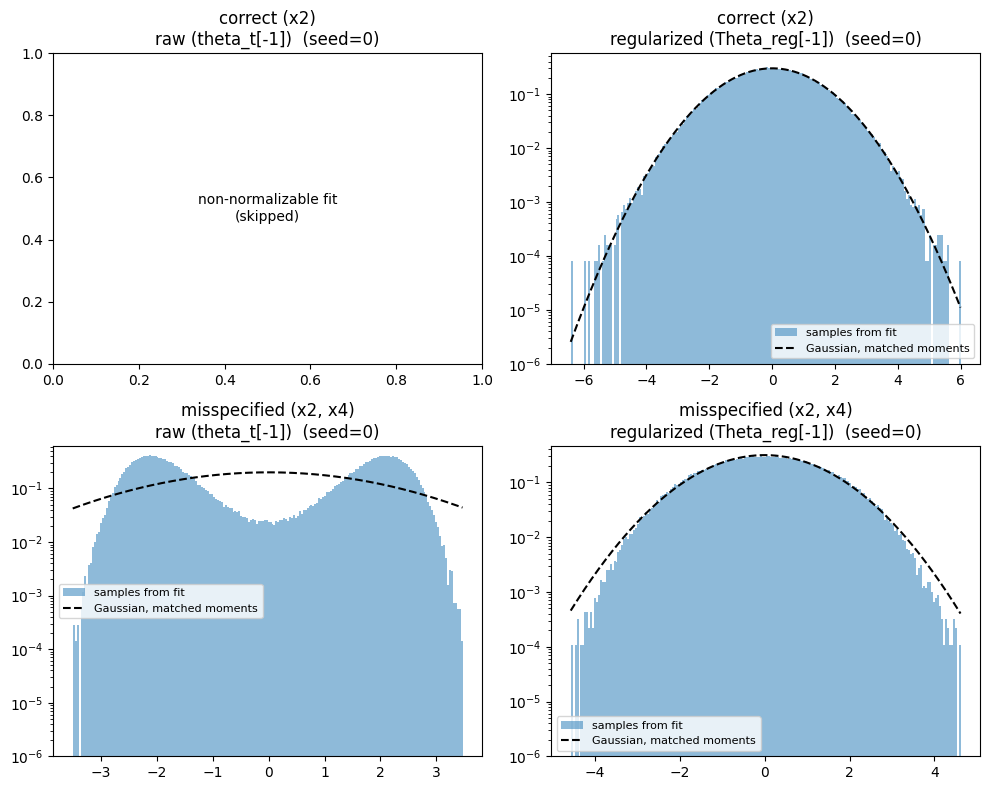

In [17]:
import matplotlib.pyplot as plt
from scipy.stats import norm

labels = list(TERM_SETS.keys())
variants = list(THETA_VARIANTS.keys())
fig, axes = plt.subplots(len(labels), len(variants),
                          figsize=(5 * len(variants), 4 * len(labels)), squeeze=False)

for r, label in enumerate(labels):
    for c, variant_label in enumerate(variants):
        ax = axes[r][c]
        x = SAMPLES_FIT.get((label, variant_label))
        ax.set_title(f"{label}\n{variant_label}  (seed={SAMPLE_SEED})")
        if x is None:
            ax.text(0.5, 0.5, 'non-normalizable fit\n(skipped)',
                    ha='center', va='center', transform=ax.transAxes)
            continue
        grid = np.linspace(x.min(), x.max(), 1000)
        ax.hist(x, bins=200, density=True, alpha=0.5, label='samples from fit')
        ax.plot(grid, norm.pdf(grid, x.mean(), x.std(ddof=1)), 'k--',
                label='Gaussian, matched moments')
        ax.set_yscale('log')                      # tails are the discriminating region
        ax.set_ylim(1e-6, None)
        ax.legend(fontsize=8)
plt.tight_layout()

## 5. Per-component energy histograms and the total log p_theta(x) distribution

Regularized (`Theta_reg[-1]`) only -- raw `theta_t[-1]` is excluded
throughout sections 5 and 6 (it was non-normalizable for `correct (x2)`
at `SAMPLE_SEED`, see cell `9a1fc247…`'s printed skip, so it can't be
compared apples-to-apples across both models anyway).

- **5.1** For each term `x^k` in a model's `terms`, the per-sample
  "energy component" `theta_k * x^k` -- i.e. one summand of the exponent
  `theta^T phi(x) = sum_k theta_k * x^k`, not `phi_k(x)` itself. This is
  the quantity that actually enters the fitted log-density, so it's the
  right one for judging how much a given term matters relative to the
  others. Compared across the correct (`x2`) vs. misspecified (`x2, x4`)
  model, both using `Theta_reg[-1]` at `SAMPLE_SEED`.
- **5.2** The full per-sample log-density `log p_theta(x) = theta^T
  phi(x) - log Z` (all components summed, normalized) -- the
  distribution of "energies" the model assigns to its own samples.
  Computes `log_Z_quad` fresh (not precomputed anywhere else for
  `Theta_reg`).

          correct (x2)  theta_x2*x^2: mean=-0.4986  std=0.7089
 misspecified (x2, x4)  theta_x2*x^2: mean=-0.3802  std=0.4917
 misspecified (x2, x4)  theta_x4*x^4: mean=-0.0604  std=0.1601


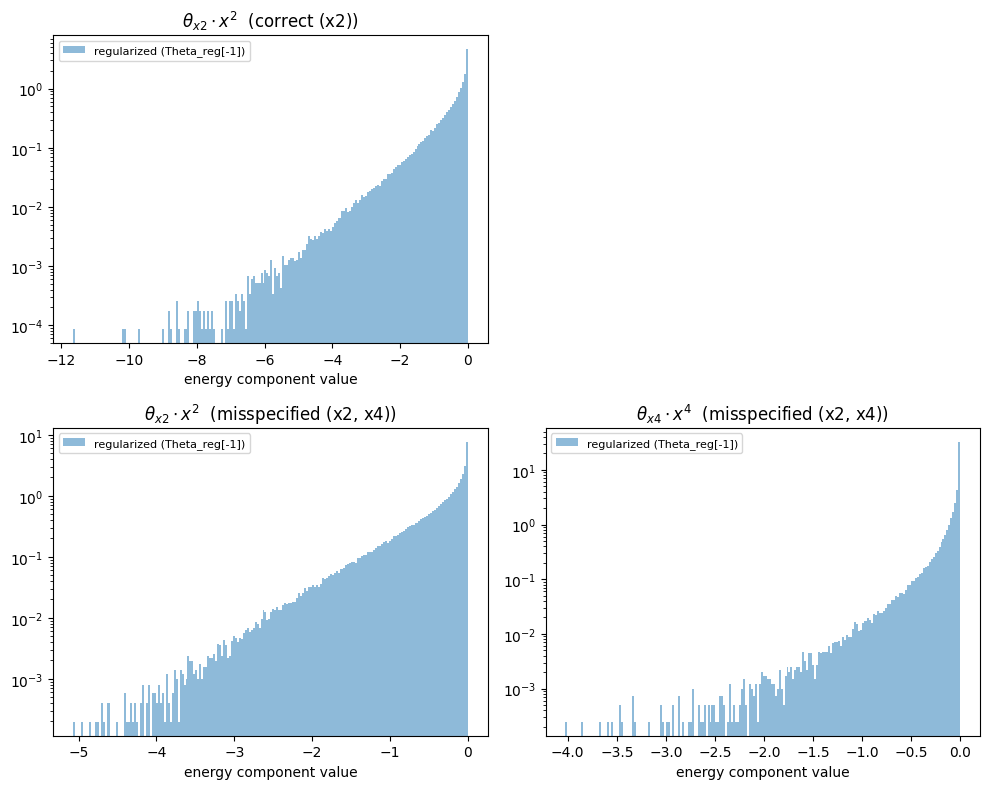

In [18]:
def energy_components(x, theta, term_names):
    """theta_k * x**k for each term -- one summand of theta^T phi(x), not phi_k(x) itself."""
    return {name: theta[i] * x ** _degree(name) for i, name in enumerate(term_names)}


REG_VARIANT_LABEL = 'regularized (Theta_reg[-1])'

n_cols = max(len(get_scalar_potentials(terms).keys()) for terms in TERM_SETS.values())
fig, axes = plt.subplots(len(TERM_SETS), n_cols,
                          figsize=(5 * n_cols, 4 * len(TERM_SETS)), squeeze=False)
comp_array = []
for r, (label, terms) in enumerate(TERM_SETS.items()):
    term_names = list(get_scalar_potentials(terms).keys())
    x = SAMPLES_FIT.get((label, REG_VARIANT_LABEL))
    for c, name in enumerate(term_names):
        ax = axes[r][c]
        if x is None:
            print(f"{label}: no regularized samples, skipping")
        else:
            theta_1 = REG_FINAL[label][SAMPLE_SEED]
            comp = energy_components(x, theta_1, term_names)[name]
            comp_array.append(comp) 
            ax.hist(comp, bins=200, density=True, alpha=0.5, label=REG_VARIANT_LABEL)
            print(f"{label:>22s}  theta_{name}*x^{_degree(name)}: "
                  f"mean={comp.mean():+.4f}  std={comp.std(ddof=1):.4f}")
        ax.set_title(rf'$\theta_{{{name}}} \cdot x^{_degree(name)}$  ({label})')
        ax.set_xlabel('energy component value')
        ax.legend(fontsize=8)
        ax.set_yscale("log")
    for c in range(len(term_names), n_cols):
        axes[r][c].axis('off')
fig.tight_layout()
plt.show()

In [19]:
comp_array

[array([-0.06137229, -0.18816548, -1.51292823, ..., -1.23134369,
        -0.20288623, -0.00894514], shape=(200000,)),
 array([-0.0124426 , -0.03409777, -0.38280923, ..., -0.35544561,
        -0.00458208, -0.00323752], shape=(200000,)),
 array([-2.42256107e-05, -1.81930109e-04, -2.29307089e-02, ...,
        -1.97696500e-02, -3.28532790e-06, -1.64012263e-06], shape=(200000,))]

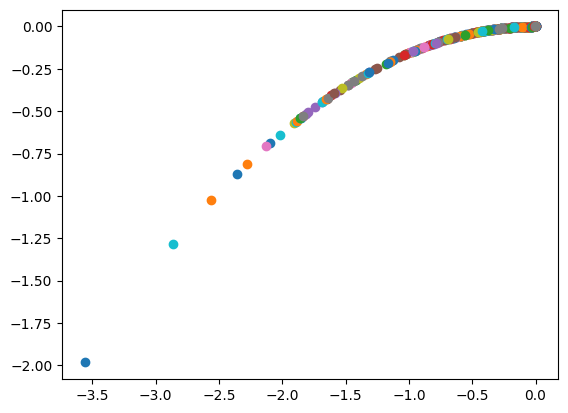

In [20]:
for i in range(0, 500): 
    plt.scatter(comp_array[1][i], comp_array[2][i]) 

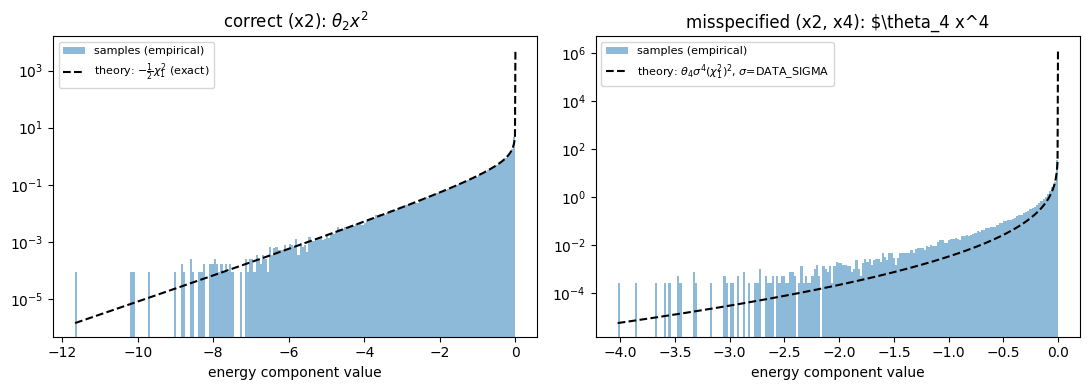

In [21]:
from scipy.stats import chi2

def theta2_component_pdf(y, theta2, sigma):
    """Exact density of Y = theta2 * X**2 for X ~ N(0, sigma**2).
    X**2 / sigma**2 ~ chi2(df=1), so Y = c*V with c = theta2*sigma**2 and
    V ~ chi2(1) -- a linear rescaling of chi2(1)."""
    c = theta2 * sigma**2
    v = y / c
    return np.where(v > 0, chi2.pdf(v, df=1) / np.abs(c), 0.0)

def theta4_component_pdf(y, theta4, sigma):
    """Exact density of Y = theta4 * X**4 for X ~ N(0, sigma**2).
    X**4 / sigma**4 = V**2 with V ~ chi2(df=1) -- the SQUARE of a chi2(1)
    variable -- so Y = c*V**2 with c = theta4*sigma**4."""
    c = theta4 * sigma**4
    w = y / c
    v = np.sqrt(np.clip(w, 0, None))
    with np.errstate(divide='ignore', invalid='ignore'):
        dens = chi2.pdf(v, df=1) / (2 * np.abs(c) * v)
    return np.where(w > 0, dens, 0.0)


fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# --- correct (x2): theta2*X^2 vs. -0.5*chi2(1), EXACT, parameter-free ---
theta2 = REG_FINAL['correct (x2)'][SAMPLE_SEED][0]
sigma_fit = np.sqrt(-1.0 / (2 * theta2))
x_correct = SAMPLES_FIT[('correct (x2)', REG_VARIANT_LABEL)]
comp2 = theta2 * x_correct ** 2

eps2 = 1e-9 * np.abs(comp2).max()
grid2 = np.linspace(comp2.min(), -eps2, 1000)
axes[0].hist(comp2, bins=200, density=True, alpha=0.5, label='samples (empirical)')
axes[0].plot(grid2, theta2_component_pdf(grid2, theta2, sigma_fit), 'k--',
             label=r'theory: $-\frac{1}{2}\chi^2_1$ (exact)')
axes[0].set_title(r'correct (x2): $\theta_2 x^2$')
axes[0].set_xlabel('energy component value')
axes[0].set_yscale('log')
axes[0].legend(fontsize=8)

# --- misspecified (x2, x4): theta4*X^4 vs. theta4*DATA_
# NOT self-consistent like the x2 case: this asks "what would this
# model's own theta4 produce if the data were exactly N(0, DATA_SIGMA^2)
# (the true generating law)" -- the gap from the empirical histogram
# measures how much the x^4 term reshapes the density be
theta4 = REG_FINAL['misspecified (x2, x4)'][SAMPLE_SEED][1]
x_misspec = SAMPLES_FIT[('misspecified (x2, x4)', REG_VARIANT_LABEL)]
comp4 = theta4 * x_misspec ** 4

eps4 = 1e-9 * np.abs(comp4).max()
grid4 = np.linspace(comp4.min(), -eps4, 1000) if theta4 < 0 else np.linspace(eps4, comp4.max(), 1000)
axes[1].hist(comp4, bins=200, density=True, alpha=0.5, label='samples (empirical)')
axes[1].plot(grid4, theta4_component_pdf(grid4, theta4, DATA_SIGMA), 'k--',
             label=r'theory: $\theta_4 \sigma^4 (\chi^2_1)^2$, $\sigma$=DATA_SIGMA')
axes[1].set_title(r'misspecified (x2, x4): $\theta_4 x^4') 
axes[1].set_xlabel('energy component value')
axes[1].set_yscale('log')
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

          correct (x2)  log p_theta(x): mean=-1.7007  std=0.7089
 misspecified (x2, x4)  log p_theta(x): mean=-1.6495  std=0.6389


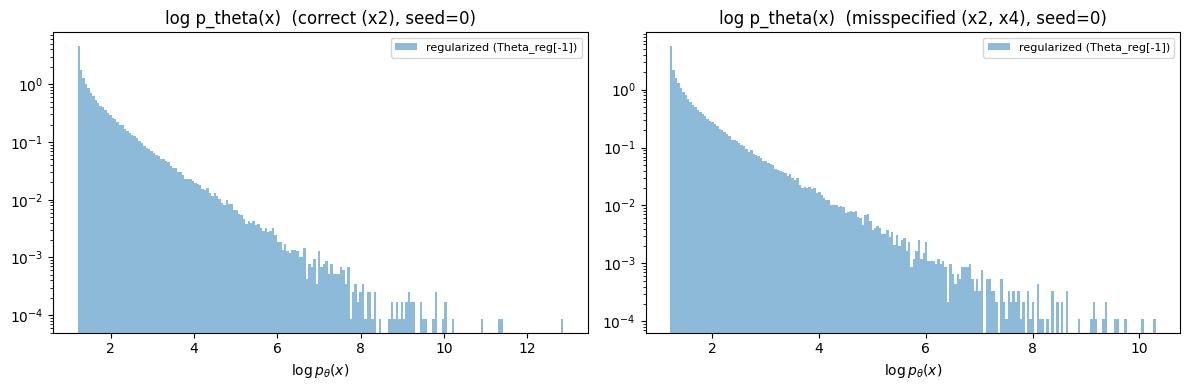

In [22]:
fig, axes = plt.subplots(1, len(TERM_SETS), figsize=(6 * len(TERM_SETS), 4), squeeze=False)
axes = axes[0]

for ax, (label, terms) in zip(axes, TERM_SETS.items()):
    term_names = list(get_scalar_potentials(terms).keys())
    x = SAMPLES_FIT.get((label, REG_VARIANT_LABEL))
    if x is None:
        print(f"{label}: no regularized samples, skipping")
        ax.set_title(f'log p_theta(x)  ({label}, seed={SAMPLE_SEED}) -- skipped')
        continue

    theta_1 = REG_FINAL[label][SAMPLE_SEED]
    lZ = log_Z_quad(theta_1, term_names)          # not precomputed elsewhere -- fresh
    log_p = log_p_unnorm(x, theta_1, term_names) - lZ
    ax.hist(-log_p, bins=200, density=True, alpha=0.5, label=REG_VARIANT_LABEL)
    print(f"{label:>22s}  log p_theta(x): mean={log_p.mean():+.4f}  std={log_p.std(ddof=1):.4f}")

    ax.set_title(f'log p_theta(x)  ({label}, seed={SAMPLE_SEED})')
    ax.set_xlabel(r'$\log p_\theta(x)$')
    ax.legend(fontsize=8)
    ax.set_yscale("log")
fig.tight_layout()
plt.show()

## 6. Single-seed log p vs. the seed-averaged theta's log p

Regularized (`Theta_reg[-1]`) only, matching the section 5 restriction --
`THETA_AVG[label] = mean over seeds of REG_FINAL[label][seed]`. Both
`log p_theta(x)` curves below are evaluated on the SAME samples,
`SAMPLES_FIT[(label, 'regularized (Theta_reg[-1])')]` (drawn from the
single seed's own regularized fit) -- so the comparison isolates "how
does the pooled theta score this seed's own realizations," the same idea
as section 5.

**Caveat:** `log p_theta(x) = theta^T phi(x) - log Z(theta)`. The first
term is linear in theta, so it's fine to average across seeds; `log
Z(theta)` is convex in theta, so `log Z(theta_avg)` is NOT the same as,
and by Jensen's inequality is `<=`, the average of the per-seed `log
Z`'s. The printed `log Z` gap below is therefore a real quantity (how
much seed noise inflates `Z` on average), not an artifact to normalize
away.

Requires `N_SEEDS > 1` actually run (cell defining `REG_FINAL`) -- with a
single cached seed, `theta_avg` trivially equals that seed's theta and
this comparison is vacuous. (100 seeds are cached as of the last run.)

In [23]:
THETA_AVG = {}
for label, terms in TERM_SETS.items():
    seeds_sorted = sorted(REG_FINAL[label])
    theta_mat = np.stack([REG_FINAL[label][s] for s in seeds_sorted])
    THETA_AVG[label] = theta_mat.mean(axis=0)
    print(f"{label:>22s}  theta_avg over {theta_mat.shape[0]} seed(s): {np.round(THETA_AVG[label], 4)}  "
          f"(seed={SAMPLE_SEED} Theta_reg[-1]: {np.round(REG_FINAL[label][SAMPLE_SEED], 4)})")

          correct (x2)  theta_avg over 100 seed(s): [-0.4882]  (seed=0 Theta_reg[-1]: [-0.2838])
 misspecified (x2, x4)  theta_avg over 100 seed(s): [-0.461 -0.005]  (seed=0 Theta_reg[-1]: [-0.2383 -0.0089])


          correct (x2)  log p (seed):      mean=-1.7007  std=0.7089
          correct (x2)  log p (theta_avg): mean=-1.7886  std=1.2195
          correct (x2)  log Z: single=1.2021  avg-theta=0.9309  (diff=-0.2712 -- NOT the same as avg(log Z) across seeds, see markdown)
 misspecified (x2, x4)  log p (seed):      mean=-1.6495  std=0.6389
 misspecified (x2, x4)  log p (theta_avg): mean=-1.7128  std=1.0322
 misspecified (x2, x4)  log Z: single=1.2088  avg-theta=0.9434  (diff=-0.2654 -- NOT the same as avg(log Z) across seeds, see markdown)


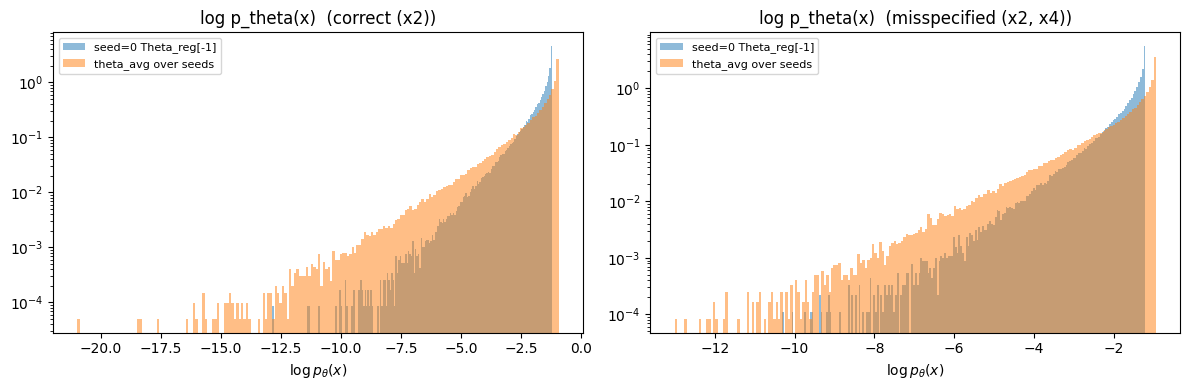

In [24]:
fig, axes = plt.subplots(1, len(TERM_SETS), figsize=(6 * len(TERM_SETS), 4), squeeze=False)
axes = axes[0]

for ax, (label, terms) in zip(axes, TERM_SETS.items()):
    term_names = list(get_scalar_potentials(terms).keys())
    x = SAMPLES_FIT.get((label, REG_VARIANT_LABEL))
    if x is None:
        print(f"{label}: no regularized samples, skipping")
        continue

    theta_single = REG_FINAL[label][SAMPLE_SEED]
    lZ_single = log_Z_quad(theta_single, term_names)
    log_p_single = log_p_unnorm(x, theta_single, term_names) - lZ_single

    theta_avg = THETA_AVG[label]
    lZ_avg = log_Z_quad(theta_avg, term_names)                     # not precomputed anywhere -- fresh
    if not np.isfinite(lZ_avg):
        print(f"{label}: theta_avg is non-normalizable, skipping")
        continue
    log_p_avg = log_p_unnorm(x, theta_avg, term_names) - lZ_avg

    ax.hist(log_p_single, bins=200, density=True, alpha=0.5, label=f'seed={SAMPLE_SEED} Theta_reg[-1]')
    ax.hist(log_p_avg, bins=200, density=True, alpha=0.5, label='theta_avg over seeds')
    ax.set_title(f'log p_theta(x)  ({label})')
    ax.set_xlabel(r'$\log p_\theta(x)$')
    ax.legend(fontsize=8)
    ax.set_yscale("log")

    print(f"{label:>22s}  log p (seed):      mean={log_p_single.mean():+.4f}  std={log_p_single.std(ddof=1):.4f}")
    print(f"{label:>22s}  log p (theta_avg): mean={log_p_avg.mean():+.4f}  std={log_p_avg.std(ddof=1):.4f}")
    print(f"{label:>22s}  log Z: single={lZ_single:.4f}  avg-theta={lZ_avg:.4f}  "
          f"(diff={lZ_avg - lZ_single:+.4f} -- NOT the same as avg(log Z) across seeds, see markdown)")

fig.tight_layout()
plt.show()

In [25]:
theta2, theta4 = THETA_AVG["misspecified (x2, x4)"] 

In [26]:
r = np.sqrt(theta2/ theta4)
r

np.float32(9.622911)

In [27]:
def log_tail_probability_robust(theta, term_names, log_Z, a, b=np.inf):
    """Same as log_tail_probability, but bounds quad to the SAME truncated
    interval [a, hi] used to compute the peak `s` -- not the literal a/b --
    which is what avoids the roundoff-driven negative `val` (-> nan) that
    log_tail_probability can hit on thin tails, independent of theta."""
    if not np.isfinite(log_Z):
        return float('nan')
    hi = min(b, a + 50.0) if not np.isfinite(b) else b
    lo = max(a, -50.0) if not np.isfinite(a) else a
    s = log_p_unnorm(np.linspace(lo, hi, 2001), theta, term_names).max()
    val, _ = quad(lambda x: np.exp(log_p_unnorm(x, theta, term_names) - s),
                  lo, hi, points=[lo, hi], limit=200)
    if val <= 0:
        return float('-inf')          # genuinely below quad's resolution, not undefined
    return s + np.log(val) - log_Z

In [28]:
OUTLIER_THRESHOLD = 4.0   

for label, terms in TERM_SETS.items():
    term_names = list(get_scalar_potentials(terms).keys())
    theta_avg = THETA_AVG[label]
    lZ_avg = log_Z_quad(theta_avg, term_names)     # fresh -- not precomputed for theta_avg anywhere
    if not np.isfinite(lZ_avg):
        print(f"{label}: theta_avg non-normalizable, skipping")
        continue

    log_p_outlier = log_tail_probability_robust(theta_avg, term_names, lZ_avg, OUTLIER_THRESHOLD, np.inf)
    p_outlier = np.exp(log_p_outlier)

    p_true = norm.sf(OUTLIER_THRESHOLD / DATA_SIGMA)   # one-sided, matches analytic N(0, DATA_SIGMA^2)
    print(f"{label:>22s}  P(X > {OUTLIER_THRESHOLD}) via theta_avg: {p_outlier:.6e}   "
          f"(true, one-sided: {p_true:.6e})")

          correct (x2)  P(X > 4.0) via theta_avg: 3.867139e-05   (true, one-sided: 3.167124e-05)
 misspecified (x2, x4)  P(X > 4.0) via theta_avg: 1.284337e-05   (true, one-sided: 3.167124e-05)
